# The Risk Playground

**25882 AI-powered Investment and Risk Management** · warm-up for Lecture 6

---

## Would you notice if your risk number was wrong?

Most people assume the hard part of risk management is *calculating* the number. It isn't.
The hard part is *checking* it — and this notebook is eight attempts to convince you of that
before the lecture does.

Almost none of it is about finance. It is about dice, cheating, traffic, weather and your own
overconfidence. Nothing here is assessed and you cannot break anything. The only thing that
matters is that you **commit to an answer before you scroll**, because half these rooms are
designed to catch you out, and they only work once.

### The eight rooms

| | Room | You will discover |
| --- | --- | --- |
| 1 | **Calibrate yourself** | your own "90% sure" is closer to 40% sure |
| 2 | **The worst case doesn't exist** | two games that standard deviation says are identical |
| 3 | **The system that never loses** | a betting strategy that VaR certifies as incapable of losing money |
| 4 | **Spot the loaded die** | you need about a thousand rolls to catch a cheat |
| 5 | **Real or fake?** | humans invent randomness that is far too tidy |
| 6 | **The airport run** | the leg you should worry about is not the unreliable one |
| 7 | **Everyone has the same map** | your navigation app creates the traffic jam it routes you around |
| 8 | **The weather forecaster** | one popular way of scoring forecasts rewards lying |

Room 3 is the one to remember. Room 4 is the one that will annoy you.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

rng = np.random.default_rng(0)

# Widgets make rooms 1, 4 and 7 much nicer, but everything works without them.
try:
    import ipywidgets as W
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

NAVY, ORANGE, RED, GREY, TEAL = "#123F69", "#E38B29", "#B22222", "#8A8A8A", "#2E7D7B"

def style(fig, title=None, xtitle=None, ytitle=None, height=380):
    fig.update_layout(template="plotly_white", height=height,
                      margin=dict(l=60, r=30, t=60 if title else 25, b=50),
                      font=dict(family="Helvetica, Arial, sans-serif", size=12),
                      colorway=[NAVY, ORANGE, GREY, TEAL, RED],
                      title=dict(text=f"<b>{title}</b>", font=dict(color=NAVY, size=15), x=0.01)
                      if title else None,
                      legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
    if xtitle: fig.update_xaxes(title=xtitle)
    if ytitle: fig.update_yaxes(title=ytitle)
    fig.update_xaxes(gridcolor="#EDEDED", zeroline=False)
    fig.update_yaxes(gridcolor="#EDEDED", zeroline=False)
    return fig

print("ready." + ("" if HAS_WIDGETS else "  (ipywidgets not found -- fallbacks will be used)"))

ready.


---
# Room 1 — Calibrate yourself

Ten questions. You almost certainly don't know any of the answers exactly, and that is the
point.

For each one, give a **range you are 90% sure contains the true answer**. Not a guess — a
range. If you are 90% sure, then on average **nine of your ten ranges should contain the
truth**.

Make them as wide as you honestly need to. There is no prize for being precise, and nobody
sees your answers.

> **Do not scroll past the button until you have submitted.** This room only works once.

In [2]:
QUESTIONS = [
    ("Length of the River Nile (km)",                       6650),
    ("Year Mozart was born",                                1756),
    ("Number of bones in an adult human body",              206),
    ("Average distance from the Earth to the Moon (km)",    384400),
    ("Height of Mount Kosciuszko (m)",                      2228),
    ("Number of United Nations member states",              193),
    ("Keys on a standard piano",                            88),
    ("Speed of light in a vacuum (km per second)",          299792),
    ("Chromosomes in a typical human body cell",            46),
    ("Depth of the Mariana Trench (m)",                     10935),
]

def score(lows, highs):
    hits = [lo <= truth <= hi for (_, truth), lo, hi in zip(QUESTIONS, lows, highs)]
    rows = []
    for (q, truth), lo, hi, ok in zip(QUESTIONS, lows, highs, hits):
        rows.append({"question": q, "your range": f"{lo:,g} to {hi:,g}",
                     "true answer": f"{truth:,}", "inside?": "yes" if ok else "NO"})
    out = pd.DataFrame(rows)
    n = sum(hits)
    print(f"\nYou said 90% confident.  You were right {n} times out of 10 ({n*10}%).")
    if n >= 9:
        print("Genuinely well calibrated. That is rare -- most people land between 3 and 6.")
    elif n >= 7:
        print("Better than most. Typical scores are 3 to 6 out of 10.")
    else:
        print("You are in the large majority. Most people score 3 to 6 -- which means their")
        print("'90% sure' is really about 40% sure. Their tails are far too thin.")
    return out

In [ ]:
if HAS_WIDGETS:
    rowsW, boxes = [], []
    for q, _ in QUESTIONS:
        lo = W.FloatText(description="low",  layout=W.Layout(width="180px"))
        hi = W.FloatText(description="high", layout=W.Layout(width="180px"))
        boxes.append((lo, hi))
        rowsW.append(W.HBox([W.HTML(f"<div style='width:330px'>{q}</div>"), lo, hi]))
    button = W.Button(description="Submit and reveal", button_style="primary",
                      layout=W.Layout(width="200px"))
    out = W.Output()

    def _submit(_):
        with out:
            clear_output()
            lows = [b[0].value for b in boxes]
            highs = [b[1].value for b in boxes]
            if all(l == 0 and h == 0 for l, h in zip(lows, highs)):
                print("Fill the ranges in first.")
                return
            display(score(lows, highs))
    button.on_click(_submit)
    display(W.VBox(rowsW + [button, out]))
else:
    print("No widgets available. Edit MY_RANGES below, then run the next cell.")

In [ ]:
# Use this instead of the widget if you prefer typing, or for a second attempt.
FORCE_FALLBACK = False

MY_RANGES = [
    (1000, 20000),      # Nile
    (1600, 1900),       # Mozart
    (100, 400),         # bones
    (100000, 900000),   # Earth-Moon
    (1000, 4000),       # Kosciuszko
    (100, 300),         # UN members
    (50, 120),          # piano keys
    (100000, 500000),   # speed of light
    (20, 80),           # chromosomes
    (5000, 15000),      # Mariana Trench
]

if not HAS_WIDGETS or FORCE_FALLBACK:
    display(score([r[0] for r in MY_RANGES], [r[1] for r in MY_RANGES]))
else:
    print("Widget above is active. Set FORCE_FALLBACK = True to use MY_RANGES instead.")

### What just happened

If you scored below 9, your 90% intervals were too narrow. Almost everyone's are — this is
one of the most reliably reproduced findings in the judgement literature.

Now notice what that *is*. You produced a range that was supposed to be breached one time in
ten, and it was breached four or five times in ten. **You built a badly calibrated risk
model.** A bank whose 99% Value at Risk is breached five times as often as it should be has
made exactly the same mistake, with more decimal places.

Everything else in this notebook is about that gap, and about how astonishingly hard it is
to detect.

---
# Room 2 — The worst case doesn't exist

Two games. You must play one of them, once.

**Game A — two coin flips.** Flip a pair of fair coins.

| Outcome | Chance | You |
| --- | --- | --- |
| two heads | 1 in 4 | win \$10 |
| one of each | 1 in 2 | break even |
| two tails | 1 in 4 | lose \$10 |

**Game B — you sell someone insurance.** They pay you a \$1 premium. Very occasionally you
have to pay a claim.

| Outcome | Chance | You |
| --- | --- | --- |
| no claim | 50 in 51 | win \$1 |
| a claim | 1 in 51 | lose \$50 |

Both games are **exactly fair** — the average outcome of each is precisely zero.

Before running anything: **which would you rather play?** Most people ask "what's the worst
that can happen?" Watch what that question does to you.

In [3]:
# Game A -- two coin flips: HH win 10, TT lose 10, one of each nothing.
A_out  = np.array([-10.0, 0.0, 10.0])
A_prob = np.array([1/4, 1/2, 1/4])

# Game B -- selling insurance: collect a $1 premium 50 times in 51, pay $50 once in 51.
# These payoffs are not arbitrary. Solving for a fair game (mean zero) with the same
# spread as Game A gives exactly $1 and $50 at odds of 1 in 51.
B_out  = np.array([-50.0, 1.0])
B_prob = np.array([1/51, 50/51])

for name, p in [("Game A", A_prob), ("Game B", B_prob)]:
    assert abs(p.sum() - 1) < 1e-12, name

def moments(out, prob):
    m = float((out * prob).sum())
    s = float(np.sqrt(((out - m) ** 2 * prob).sum()))
    return m, s

for name, o, p in [("Game A", A_out, A_prob), ("Game B", B_out, B_prob)]:
    m, s = moments(o, p)
    print(f"{name}:  mean {m:+.3f}   standard deviation {s:.3f}")

Game A:  mean +0.000   standard deviation 7.071
Game B:  mean +0.000   standard deviation 7.071


**Standard deviation cannot tell these two games apart.** Same mean, same spread. If risk
means volatility, they are the same game.

They are obviously not the same game. So let us ask the two questions a risk manager asks.

- **Value at Risk (95%)** — how much do I lose on a bad day, where "bad" means the worst 1
  day in 20?
- **Expected Shortfall (95%)** — *when* it's that bad or worse, how much do I lose **on
  average**?

In [4]:
def var_es(out, prob, conf):
    # VaR and ES of a discrete payoff. Losses are positive numbers.
    loss = -np.asarray(out, dtype=float)
    order = np.argsort(loss)
    loss, prob = loss[order], np.asarray(prob, dtype=float)[order]
    var = float(loss[np.searchsorted(np.cumsum(prob), conf - 1e-12)])
    need, taken, acc = 1 - conf, 0.0, 0.0
    for l, p in zip(loss[::-1], prob[::-1]):
        use = min(p, need - taken)
        acc += l * use
        taken += use
        if taken >= need - 1e-15:
            break
    return var, acc / need

rows = {}
for name, o, p in [("Game A", A_out, A_prob), ("Game B", B_out, B_prob)]:
    m, s = moments(o, p)
    v95, e95 = var_es(o, p, 0.95)
    v99, e99 = var_es(o, p, 0.99)
    rows[name] = {"mean": m, "std dev": s, "VaR 95%": v95, "ES 95%": e95,
                  "VaR 99%": v99, "ES 99%": e99}
display(pd.DataFrame(rows).T.style.format("{:+.2f}")
        .set_caption("Losses are positive. Negative means you make money."))

,mean,std dev,VaR 95%,ES 95%,VaR 99%,ES 99%
Game A,+0.00,+7.07,+10.00,+10.00,+10.00,+10.00
Game B,+0.00,+7.07,-1.00,+19.00,+50.00,+50.00


Read the `VaR 95%` column slowly.

**Game A's 95% VaR is +10. Game B's is −1.** A negative loss is a profit. At the 95%
confidence level, Value at Risk says Game B *cannot lose you money* — and therefore that
Game B is the safer bet.

Now read `ES 95%`. Game A: 10. Game B: **19**. Expected Shortfall says Game B is nearly
twice as dangerous.

Same two games. Three measures. Three different answers, including one that is flatly
misleading.

The reason is simple once you see it. **VaR is a quantile — it tells you where the tail
starts and nothing about what is inside it.** Game B's claim arrives 1 time in 51, or 1.96%
of the time — which sits just *outside* the worst-5% window, so VaR at 95% looks straight
past it and reports the \$1 premium instead. ES averages over the whole tail, so it cannot.

Push the confidence level to 99% and VaR finally sees the claim (it jumps to 50), because
1.96% now falls *inside* the worst-1% window. **Nothing about the game changed — only where
you drew the line.** A risk number that flips this hard on the choice of threshold is telling
you something about the threshold, not about the risk.

> "What's the worst that can happen?" has no answer. The worst that can happen is always
> *everything*, with some very small probability. The only sensible questions are "how bad,
> how often" — and those are two different numbers.

---
# Room 3 — The system that never loses

This one is a genuine classic, and it has bankrupted real people.

**The martingale.** Bet \$1 on a coin flip. If you win, pocket \$1 and start again. If you
lose, bet \$2. Lose again, bet \$4. Then \$8, \$16, \$32, \$64.

You only need to win **once** to come out exactly \$1 ahead. And you will win eventually,
because the coin is fair.

Before running the cell: **how often do you think this loses?**

In [5]:
DOUBLINGS = 7                    # bets of 1, 2, 4, ..., 64
max_stake = 2 ** DOUBLINGS - 1   # total you can lose in one session
p_ruin = 0.5 ** DOUBLINGS

print(f"You can absorb {DOUBLINGS} losses in a row, staking at most ${max_stake}.")
print(f"Probability all {DOUBLINGS} flips go against you: {p_ruin:.6f}  =  1 in {2**DOUBLINGS}")
print()

M_out  = np.array([-float(max_stake), 1.0])
M_prob = np.array([p_ruin, 1 - p_ruin])
m, s = moments(M_out, M_prob)
print(f"Expected profit per session: ${m:+.4f}   (a fair coin, so a fair game)")
print(f"Sessions won: {1-p_ruin:.4%}    Sessions lost: {p_ruin:.4%}")

You can absorb 7 losses in a row, staking at most $127.
Probability all 7 flips go against you: 0.007812  =  1 in 128

Expected profit per session: $+0.0000   (a fair coin, so a fair game)
Sessions won: 99.2188%    Sessions lost: 0.7812%


In [6]:
rows = {}
for conf in (0.90, 0.95, 0.99, 0.995):
    v, e = var_es(M_out, M_prob, conf)
    rows[f"{conf:.1%}"] = {"VaR": v, "ES": e}
display(pd.DataFrame(rows).T.style.format("{:+.2f}")
        .set_caption("The martingale. Losses positive; negative = profit."))

print(f"VaR only becomes a loss above {1 - p_ruin:.4%} confidence.")

,VaR,ES
90.0%,-1.00,+9.00
95.0%,-1.00,+19.00
99.0%,-1.00,+99.00
99.5%,+127.00,+127.00


VaR only becomes a loss above 99.2188% confidence.


### The punchline

**At 99% confidence, Value at Risk says this strategy makes money.** VaR is −1: a guaranteed
profit of one dollar.

**At the same 99% confidence, Expected Shortfall says you lose 99 times your unit stake.**

Both numbers are correct. They are answers to different questions, and only one of them is
the question you actually care about.

A risk report that quotes 99% VaR for this strategy is not lying, is not miscalculated, and
would pass an audit. It simply describes a threshold that the disaster sits just beyond.

Run it and watch.

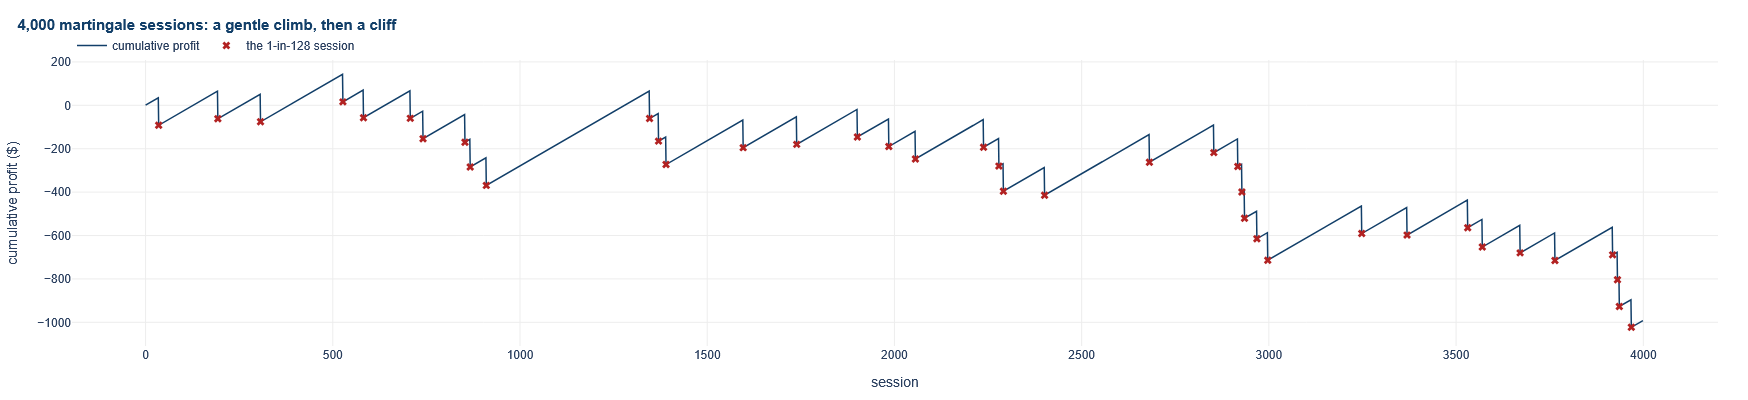

Sessions won: 3,961   lost: 39
Longest winning streak before a bust: 436 sessions
Final profit after 4,000 sessions: $-992


In [7]:
def play_session(rng, doublings=DOUBLINGS):
    stake = 1
    for _ in range(doublings):
        if rng.random() < 0.5:
            return 1
        stake *= 2
    return -(2 ** doublings - 1)

r = np.random.default_rng(2)
N = 4000
pnl = np.array([play_session(r) for _ in range(N)])
equity = np.cumsum(pnl)

fig = go.Figure()
fig.add_trace(go.Scatter(y=equity, mode="lines", name="cumulative profit",
                         line=dict(color=NAVY, width=1.5)))
busts = np.flatnonzero(pnl < 0)
fig.add_trace(go.Scatter(x=busts, y=equity[busts], mode="markers", name="the 1-in-128 session",
                         marker=dict(color=RED, size=7, symbol="x")))
style(fig, title=f"{N:,} martingale sessions: a gentle climb, then a cliff",
      xtitle="session", ytitle="cumulative profit ($)", height=400)
fig.show()

print(f"Sessions won: {(pnl > 0).sum():,}   lost: {(pnl < 0).sum():,}")
print(f"Longest winning streak before a bust: {np.diff(np.r_[-1, busts]).max():,} sessions")
print(f"Final profit after {N:,} sessions: ${equity[-1]:+,.0f}")

Look at the shape. Long, smooth, reassuring climbs — the exact shape that makes a strategy
look brilliant in a backtest, a fund look skilled in its first three years, and a trader look
like a genius right up until they don't.

**Nothing about the upward stretch tells you the cliff is coming.** The cliff was always in
the distribution. It just hadn't happened yet.

Try `DOUBLINGS = 10` and rerun. The strategy wins 99.9% of sessions. It also loses \$1,023
when it loses.

---
# Room 4 — Spot the loaded die

Someone hands you a die. You suspect it rolls sixes too often — not blatantly, just a bit.
Instead of one time in six (16.7%), it comes up one time in five (20%).

**Before running anything: how many rolls do you think you need to prove it?**

Write a number down. Most people say somewhere between 30 and 100.

In [8]:
MY_GUESS = 60          # <-- put your guess here before running the rest

def detection_rate(p_true, n_rolls, alpha=0.05, sims=20000, seed=1):
    # How often does a standard test correctly flag a die with P(six) = p_true?
    #
    # This uses a normal approximation, which is fine here because a six turns up
    # about 1 roll in 6. Do NOT reuse it for rare events: with a 99% VaR you expect
    # only ~2.5 breaches in 250 days, and the approximation overstates the power by
    # more than half. Notebook 06c uses the proper Kupiec likelihood-ratio test.
    r = np.random.default_rng(seed)
    sixes = r.binomial(n_rolls, p_true, sims)
    p0 = 1 / 6
    se = np.sqrt(n_rolls * p0 * (1 - p0))
    z = np.abs(sixes - n_rolls * p0) / se
    return float(np.mean(z > 1.96))

print(f"With your {MY_GUESS} rolls, you would catch this die "
      f"{detection_rate(0.20, MY_GUESS):.0%} of the time.")

With your 60 rolls, you would catch this die 14% of the time.


,slightly loaded P(six)=0.20,blatantly loaded P(six)=0.25
rolls,,
30,6%,20%
60,14%,43%
120,15%,61%
250,29%,91%
500,52%,100%
1000,79%,100%
2000,97%,100%
4000,100%,100%


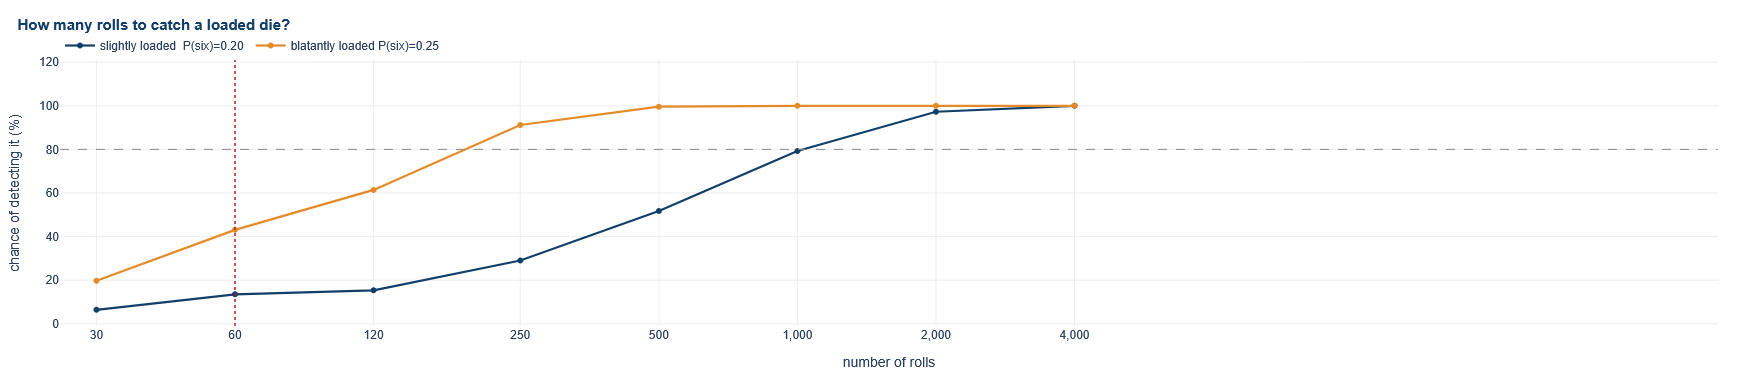

In [35]:
sizes = [30, 60, 120, 250, 500, 1000, 2000, 4000]
table = pd.DataFrame({
    "slightly loaded  P(six)=0.20": [detection_rate(0.20, n) for n in sizes],
    "blatantly loaded P(six)=0.25": [detection_rate(0.25, n) for n in sizes],
}, index=sizes)
table.index.name = "rolls"
display(table.style.format("{:.0%}").set_caption("Probability of catching the cheat"))

fig = go.Figure()
for col, colour in zip(table.columns, [NAVY, ORANGE]):
    fig.add_trace(go.Scatter(x=sizes, y=table[col] * 100, mode="lines+markers",
                             name=col, line=dict(color=colour, width=2.2)))
fig.add_vline(x=MY_GUESS, line=dict(color=RED, dash="dot", width=1.5),
              annotation_text="your guess", annotation_position="top")
fig.add_hline(y=80, line=dict(color=GREY, dash="dash", width=1))
style(fig, title="How many rolls to catch a loaded die?",
      xtitle="number of rolls", ytitle="chance of detecting it (%)", height=380)

# NOTE: when type="log", the axis range is in LOG10 units, not rolls.
# range=[25, 4600] would mean 10^25 to 10^4600 and the data would vanish.
lo = min(min(sizes), MY_GUESS) * 0.85
hi = max(sizes) * 10
#fig.update_xaxes(type="log", range=[np.log10(lo), np.log10(hi)], tickvals=sizes, ticktext=[f"{n:,}" for n in sizes])
fig.update_xaxes(type="log", range=[np.log10(25), np.log10(100000)], tickvals=sizes, ticktext=[f"{n:,}" for n in sizes])
fig.update_yaxes(range=[-1, 121])
fig.show()

### About a thousand rolls

To have a reasonable (80%) chance of catching a die that rolls sixes 20% of the time instead
of 16.7%, you need roughly **1,000 rolls**. At 60 rolls you would catch it about one time in
seven. You would conclude the die is fine, and you would be wrong.

The blatant cheat is easy — 250 rolls gets you there. The *subtle* one is nearly invisible.

### Why this is the most important room in the notebook

Swap the words and you have the entire practice of risk model validation:

| | The die | A bank's risk model |
| --- | --- | --- |
| claims | P(six) = 1/6 | 99% VaR, breached 1 day in 100 |
| actually | P(six) = 0.20 — 1.2x too often | breached 1.5 days in 100 — **1.5x** too often |
| one observation | one roll | one trading day |
| the event you count | a six, once every 6 rolls | a breach, once every 100 days |
| rolls/days for a good chance of catching it | ~1,050 | **~3,700 — about 15 years** |
| events collected by then | 175 sixes | **37 breaches** |

Look at the last two rows together, because they explain each other.

The bank's model is the *more* wrong of the two — off by half rather than a fifth. So it
needs **fewer** events to prove it: 37 breaches, against 175 sixes. But a breach only turns up
once every hundred days. Collecting 37 of them takes fifteen years.

> **Rare events carry the least information exactly where you need it most.** You cannot fix
> this by being cleverer. The data arrives at the rate it arrives.

Regulators check risk models over a **250-day** window. At that length, a model breaching half
again as often as it claims is caught about **one time in nine**.

> **Passing a backtest is weak evidence. Failing one is strong evidence.** Treat the two
> outcomes very differently — most people treat them the same.

---
# Room 5 — Real or fake?

Below are two sequences of 100 coin flips. One came from an actual random number generator.
The other was invented by a person trying to *look* random.

**Pick the real one before you run the checking cell.**

In [12]:
def human_style(n, switch_p=0.72, seed=5):
    # People asked to fake coin flips alternate far more often than chance.
    r = np.random.default_rng(seed)
    s = [int(r.integers(0, 2))]
    for _ in range(n - 1):
        s.append(1 - s[-1] if r.random() < switch_p else s[-1])
    return np.array(s)

seq_X = np.random.default_rng(42).integers(0, 2, 100)   # which is which is revealed below
seq_Y = human_style(100)
show = {0: "T", 1: "H"}

for label, s in [("Sequence X", seq_X), ("Sequence Y", seq_Y)]:
    line = "".join(show[v] for v in s)
    print(f"{label}:  {line[:50]}")
    print(f"             {line[50:]}\n")

Sequence X:  THHTTHTHTTHHHHHHHTHTHTTHHHTHHTTTTHHTHHTHTHHTTHTHHH
             HTTTTTHTHHHHTHTTHTTTHTTTHTTTHHHTTHHHTTHHTHHTHTTHHT

Sequence Y:  HHTHTHTHTTHTHHHHTHTHTHHTHHTTTHTHTHTHHTHTHHTHHTHTHH
             TTHHTTHTTHTHTHTHTHHTHHTHTTTTTHTTHTHHTHTHTTTHHTTHTH



In [15]:
MY_PICK = "?"        # <-- change to "X" or "Y" BEFORE running this cell

def longest_run(s):
    best = cur = 1
    for i in range(1, len(s)):
        cur = cur + 1 if s[i] == s[i - 1] else 1
        best = max(best, cur)
    return best

for label, s in [("Sequence X", seq_X), ("Sequence Y", seq_Y)]:
    switches = int(np.sum(s[1:] != s[:-1]))
    print(f"{label}: {int(s.sum())} heads, {switches} switches, longest run {longest_run(s)}")
if MY_PICK not in ("X", "Y"):
    print("\nSet MY_PICK to \"X\" or \"Y\" above, then rerun this cell for the answer.")
else:
    print(f"\nThe real one is X.  You picked {MY_PICK} -- "
          f"{'correct' if MY_PICK == 'X' else 'and you are in good company'}.")

Sequence X: 52 heads, 52 switches, longest run 7
Sequence Y: 51 heads, 70 switches, longest run 5

Set MY_PICK to "X" or "Y" above, then rerun this cell for the answer.


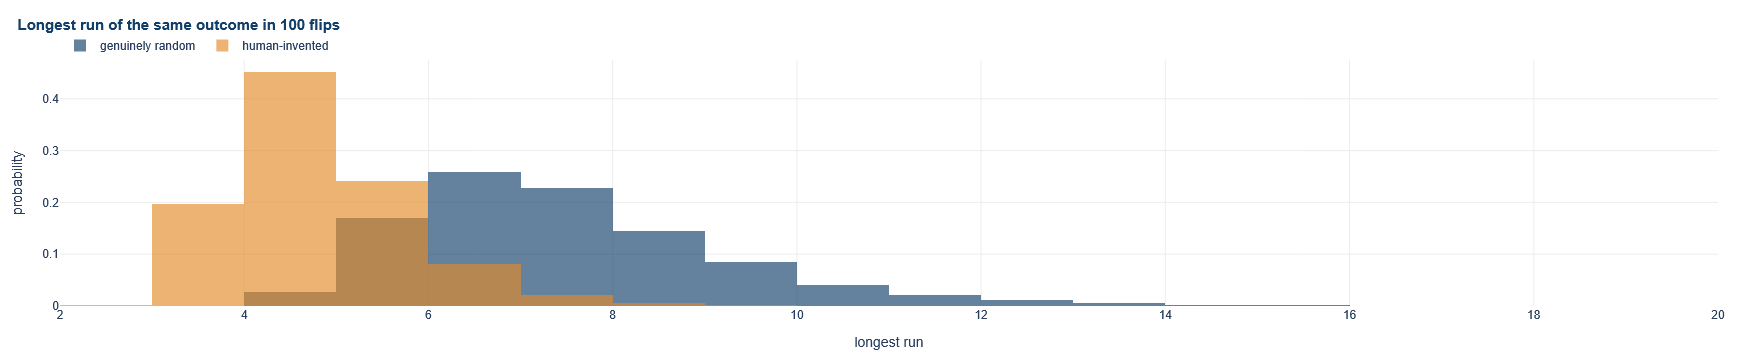

genuinely random: average longest run 7.0, 80% have a run of 6 or more
human-invented:   average longest run 4.3, 11% have a run of 6 or more


In [16]:
r = np.random.default_rng(7)
real = [longest_run(r.integers(0, 2, 100)) for _ in range(20000)]
fake = [longest_run(human_style(100, seed=int(s))) for s in r.integers(0, 10**6, 20000)]

fig = go.Figure()
for vals, name, colour in [(real, "genuinely random", NAVY), (fake, "human-invented", ORANGE)]:
    fig.add_trace(go.Histogram(x=vals, name=name, marker_color=colour, opacity=0.65,
                               xbins=dict(start=1, end=20, size=1), histnorm="probability"))
style(fig, title="Longest run of the same outcome in 100 flips",
      xtitle="longest run", ytitle="probability", height=360)
fig.update_layout(barmode="overlay")
fig.show()

print(f"genuinely random: average longest run {np.mean(real):.1f}, "
      f"{np.mean(np.array(real) >= 6):.0%} have a run of 6 or more")
print(f"human-invented:   average longest run {np.mean(fake):.1f}, "
      f"{np.mean(np.array(fake) >= 6):.0%} have a run of 6 or more")

### Randomness is clumpier than you think

In 100 fair coin flips you should *expect* a run of about seven identical outcomes. People
inventing a random sequence almost never write one — a run of six feels like a mistake, so
they break it up.

This cuts both ways, and both ways matter:

- **We see patterns in randomness.** A fund manager with five good years, a basketball player
  on a "hot streak", a run of losses that feels like something has broken.
- **We see randomness in patterns.** Genuine clustering — where a bad day really does make
  the next bad day more likely — looks unremarkable to the naked eye.

The second is the dangerous one for risk management. In real markets, **bad days cluster**.
A risk model can be breached exactly the right *number* of times and still be badly wrong,
because all the breaches arrived in the same fortnight.

That is a model whose *level* is calibrated but whose *timing* is not — and it is wrong at
precisely the moment you need it to be right. Lecture 6 gives you a formal test for it.

---
# Room 6 — The airport run

You have a flight. Getting to the gate has five stages, each of uncertain duration:

| Stage | Typical | How unreliable |
| --- | --- | --- |
| Taxi to the airport | 35 min | **very** — traffic is unpredictable |
| Bag drop queue | 12 min | moderate |
| Security queue | 15 min | moderate |
| Passport control | 10 min | moderate |
| Walk to the gate | 8 min | barely varies |

**Which stage should you worry about most?**

Nearly everyone says the taxi, and the reasoning is sound: it has by far the widest spread of
outcomes. Let us check.

In [17]:
legs = ["Taxi", "Bag drop", "Security", "Passport", "Walk to gate"]
mean_min = np.array([35.0, 12.0, 15.0, 10.0, 8.0])
own_sd   = np.array([13.0,  9.0,  9.0,  9.0, 2.0])

# The three queues share a cause -- a busy day at the terminal makes ALL of them slow.
# The taxi does not care how busy the terminal is.
q, t = 0.80, 0.05
corr = np.array([[1, t, t, t, 0],
                 [t, 1, q, q, 0],
                 [t, q, 1, q, 0],
                 [t, q, q, 1, 0],
                 [0, 0, 0, 0, 1]], dtype=float)
cov = np.outer(own_sd, own_sd) * corr

total_sd = float(np.sqrt(np.ones(5) @ cov @ np.ones(5)))
contribution = (cov @ np.ones(5)) / total_sd        # Euler decomposition

table = pd.DataFrame({"typical (min)": mean_min, "own variability": own_sd,
                      "contribution to risk": contribution,
                      "share of total risk": contribution / contribution.sum()}, index=legs)
display(table.style.format({"typical (min)": "{:.0f}", "own variability": "{:.0f}",
                            "contribution to risk": "{:.2f}",
                            "share of total risk": "{:.1%}"}))
print(f"Whole journey: {mean_min.sum():.0f} min on average, spread {total_sd:.1f} min")
print(f"Contributions sum to {contribution.sum():.4f} -- exactly the total spread. "
      "That is not a coincidence.")

,typical (min),own variability,contribution to risk,share of total risk
Taxi,35,13,6.44,22.2%
Bag drop,12,9,7.47,25.8%
Security,15,9,7.47,25.8%
Passport,10,9,7.47,25.8%
Walk to gate,8,2,0.14,0.5%


Whole journey: 80 min on average, spread 29.0 min
Contributions sum to 28.9810 -- exactly the total spread. That is not a coincidence.


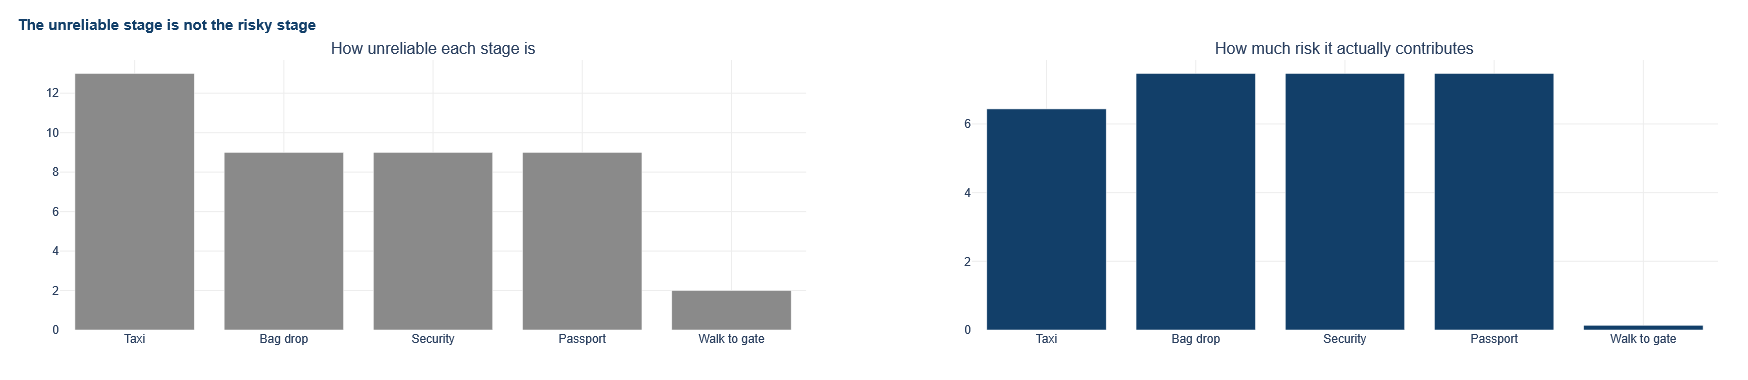

Most unreliable stage : Taxi
Biggest risk contributor: Bag drop
The taxi is 44% MORE variable than security, yet contributes 14% LESS risk.
The three queues together account for 77% of everything that can go wrong.


In [18]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("How unreliable each stage is",
                                                    "How much risk it actually contributes"))
fig.add_trace(go.Bar(x=legs, y=own_sd, marker_color=GREY, showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=legs, y=contribution, marker_color=NAVY, showlegend=False), row=1, col=2)
style(fig, title="The unreliable stage is not the risky stage", height=380)
fig.show()

worst_sd = legs[int(np.argmax(own_sd))]
worst_rc = legs[int(np.argmax(contribution))]
print(f"Most unreliable stage : {worst_sd}")
print(f"Biggest risk contributor: {worst_rc}")
print(f"The taxi is {own_sd[0]/own_sd[2]-1:.0%} MORE variable than security, "
      f"yet contributes {1-contribution[0]/contribution[2]:.0%} LESS risk.")
print(f"The three queues together account for {contribution[1:4].sum()/contribution.sum():.0%} "
      "of everything that can go wrong.")

### Why the taxi is a red herring

The taxi is unreliable, but it is unreliable **on its own**. A bad traffic day tells you
nothing about the security queue.

The three queues are individually less variable — but they go wrong **together**. A busy
morning at the terminal means a long bag drop *and* a long security queue *and* a long
passport queue. Their problems arrive as one problem, and that is what makes them dangerous.

> An item's contribution to total risk depends on **how it moves with everything else**, not
> just on how much it moves.

This is the single most useful idea in portfolio construction, and you have just derived it
by trying to catch a plane. Notice too that the contributions summed *exactly* to the total —
that identity is what lets you treat risk as a budget you allocate, which is where Lecture 6
ends up.

**Try this:** set `q = 0.0` (the queues become independent) and rerun. The taxi becomes the
biggest contributor again, exactly as intuition said. The intuition was not stupid — it was
just ignoring correlation.

---
# Room 7 — Everyone has the same map

You have almost certainly experienced this. There is a jam on the motorway, your navigation
app diverts you down a side street — and the side street is packed, with everybody else who
was also diverted.

Let us build it. Five hundred drivers, two routes, every morning. Each driver estimates how
long each route took recently and picks the faster one. A route gets slower the more people
choose it.

Nothing here is malicious, irrational, or badly designed. Every driver is doing the sensible
thing.

In [19]:
def commute(n_drivers=500, days=200, base=20.0, congestion=0.02,
            reaction=0.6, reaction_spread=0.0, private_info=0.0, burn=50, seed=3):
    # Each morning: estimate, choose the faster route, and by choosing make it slower.
    #
    # private_info : how much drivers' information differs from one another.
    #                0 means everyone sees exactly the same thing.
    r = np.random.default_rng(seed)
    speed = np.clip(r.normal(reaction, reaction_spread, n_drivers), 0.03, 1.0)
    est_A = base + r.normal(0, 2, n_drivers)
    est_B = base + r.normal(0, 2, n_drivers)

    log = []
    for _ in range(days):
        take_A = est_A < est_B
        nA = int(take_A.sum()); nB = n_drivers - nA
        time_A = base + congestion * nA + r.normal(0, 0.5)
        time_B = base + congestion * nB + r.normal(0, 0.5)
        seen_A = time_A + r.normal(0, private_info, n_drivers)
        seen_B = time_B + r.normal(0, private_info, n_drivers)
        est_A = (1 - speed) * est_A + speed * seen_A
        est_B = (1 - speed) * est_B + speed * seen_B
        log.append((nA, time_A, time_B))

    h = pd.DataFrame(log, columns=["on_A", "time_A", "time_B"]).iloc[burn:]
    experienced = (h.time_A * h.on_A + h.time_B * (n_drivers - h.on_A)) / n_drivers
    return h, experienced

IDEAL = 20.0 + 0.02 * 500 / 2
print(f"If drivers split perfectly 250/250 every day, everyone's commute is {IDEAL:.1f} min.")
print("That is the best achievable. Now let them choose for themselves.")

If drivers split perfectly 250/250 every day, everyone's commute is 25.0 min.
That is the best achievable. Now let them choose for themselves.


In [20]:
scenarios = {
    "everyone runs the same model":      dict(private_info=0.0, reaction_spread=0.0),
    "same model, different reaction speeds": dict(private_info=0.0, reaction_spread=0.30),
    "drivers have different information":  dict(private_info=5.0, reaction_spread=0.0),
}
results, summary = {}, {}
for name, kw in scenarios.items():
    h, exp = commute(**kw)
    results[name] = (h, exp)
    summary[name] = {"swing in the split (drivers)": h.on_A.std(),
                     "average commute (min)": exp.mean(),
                     "worst day (min)": exp.max(),
                     "vs ideal": exp.mean() / IDEAL - 1}
display(pd.DataFrame(summary).T.style.format({
    "swing in the split (drivers)": "{:.0f}", "average commute (min)": "{:.1f}",
    "worst day (min)": "{:.1f}", "vs ideal": "{:+.0%}"}))

,swing in the split (drivers),average commute (min),worst day (min),vs ideal
everyone runs the same model,251,30.0,31.3,+20%
"same model, different reaction speeds",248,29.9,31.3,+20%
drivers have different information,27,25.0,25.9,+0%


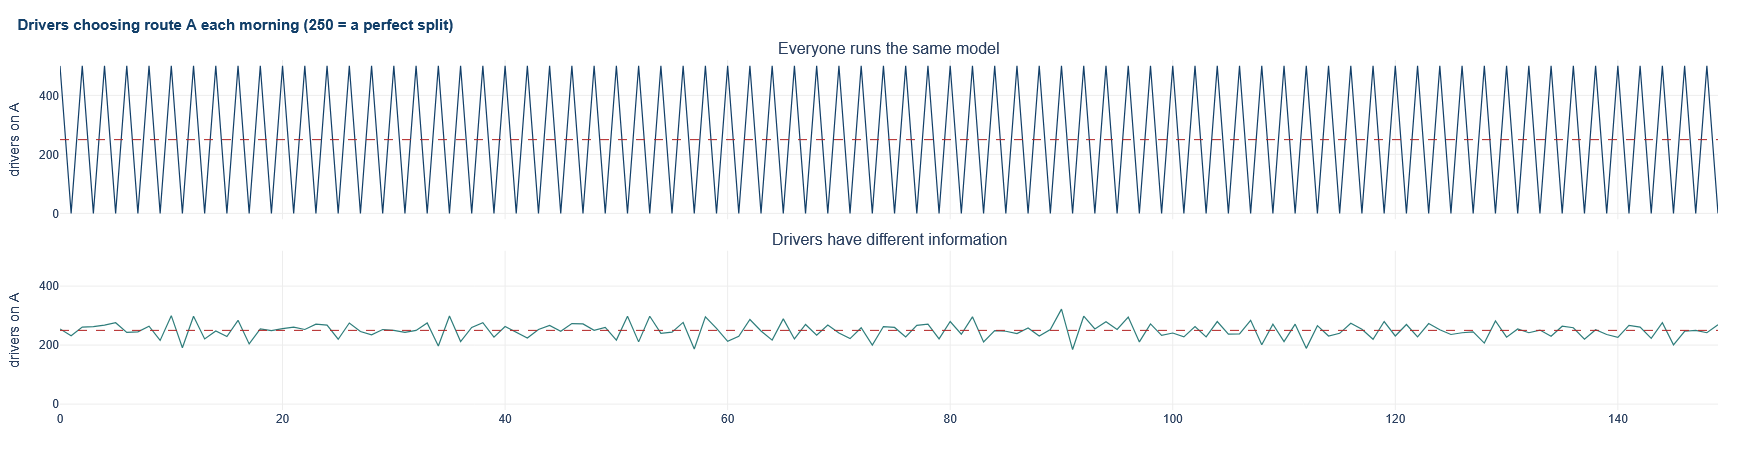

In [21]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.09,
                    subplot_titles=("Everyone runs the same model",
                                    "Drivers have different information"))
for row, key in enumerate(["everyone runs the same model",
                           "drivers have different information"], start=1):
    h, _ = results[key]
    fig.add_trace(go.Scatter(y=h.on_A.to_numpy(), mode="lines",
                             line=dict(color=NAVY if row == 1 else TEAL, width=1.2),
                             showlegend=False), row=row, col=1)
    fig.add_hline(y=250, line=dict(color=RED, dash="dash", width=1), row=row, col=1)
style(fig, title="Drivers choosing route A each morning (250 = a perfect split)", height=460)
fig.update_yaxes(range=[-20, 520], title="drivers on A")
fig.show()

### Three findings, one of which surprised me

**First: identical models produce a stampede.** When everyone has the same information and
the same rule, they all switch at the same time. The split thrashes between nearly-all-A and
nearly-all-B. Nobody is ever on the quiet road, because the moment a road is quiet, everyone
goes there.

**Second: reacting at different speeds does not help.** This one I expected to work and it
does not — the numbers barely move. If everyone is looking at the same information, changing
*how fast* they respond does not change *what* they conclude. They still all conclude it
together.

**Third: different information fixes it.** Give drivers genuinely different views of the
road and the stampede stops. The split settles near the ideal, the average commute drops by
about five minutes, and the worst day improves substantially.

> Diversity of models is not a nice-to-have. It is what stops the system oscillating —
> and every individual driver is better off for it, including the ones with worse information.

### Why this is in a risk management course

Volatility rises, so every risk model says reduce exposure, so everybody sells, so volatility
rises. The risk model stops being a *measuring instrument* and becomes a *coordination
device*.

And here is the uncomfortable part for a subject about AI. Better models are more accurate.
But if everyone trains on the same data with the same architectures, better models are also
**more alike** — and this room shows what "more alike" does. Accuracy and diversity are both
virtues, and they are not the same virtue.

**Stretch:** give the two routes different capacities, or add a third route, or let a
fraction of drivers ignore the app entirely. How large does the stubborn minority need to be
before it stabilises everyone else?

---
# Room 8 — The weather forecaster

Two forecasters. Yesterday one said 70% chance of rain and it rained. The other said 90% and
it stayed dry.

**Who is better?** You cannot tell from one day. So how do you *ever* tell?

This is not a pedantic question. It is the question of how you score any forecast, and it
turns out that some obvious ways of scoring are actively harmful.

In [22]:
from scipy import stats

r = np.random.default_rng(11)
n = 20000
latent = r.normal(0, 1, n)
rained = latent > 0.674                          # about 25% of days
signal = latent + r.normal(0, 1.0, n)            # a forecaster's noisy view

# a skilled, honestly calibrated forecaster reports the true posterior
skilled = np.clip(1 - stats.norm.cdf((0.674 - signal / 2) / np.sqrt(0.5)), 0.001, 0.999)
never   = np.full(n, 0.02)                       # "it basically never rains"
brash   = np.clip((skilled - 0.5) * 2.2 + 0.5, 0.001, 0.999)   # right idea, overstated

def accuracy(f, y): return float(np.mean((f >= 0.5) == y))
def brier(f, y):    return float(np.mean((f - y) ** 2))
def log_score(f, y):
    f = np.clip(f, 1e-9, 1 - 1e-9)
    return float(-np.mean(y * np.log(f) + (1 - y) * np.log(1 - f)))
def mean_abs(f, y): return float(np.mean(np.abs(f - y)))

print(f"It actually rained on {rained.mean():.1%} of days.\n")
scores = pd.DataFrame({
    name: {"accuracy": accuracy(f, rained), "Brier score": brier(f, rained),
           "log score": log_score(f, rained), "mean absolute error": mean_abs(f, rained)}
    for name, f in [("'it never rains'", never), ("skilled and honest", skilled),
                    ("skilled but overconfident", brash)]}).T
display(scores.style.format({"accuracy": "{:.1%}", "Brier score": "{:.4f}",
                             "log score": "{:.4f}", "mean absolute error": "{:.4f}"}))

It actually rained on 24.9% of days.



,accuracy,Brier score,log score,mean absolute error
'it never rains',75.1%,0.2392,0.9885,0.2588
skilled and honest,81.4%,0.1295,0.4012,0.2597
skilled but overconfident,81.4%,0.1484,0.7182,0.1997


Three things to notice, in increasing order of how much they should bother you.

**Accuracy is nearly useless here.** The forecaster who simply says "it never rains" is right
75% of the time — barely worse than the skilled one, and they are not forecasting at all.
Any metric that a constant answer can nearly win is not measuring skill.

**Accuracy cannot see overconfidence at all.** The honest and the overconfident forecaster
have *identical* accuracy. They differ enormously in how much you should trust a "90%".
Brier and the log score both see it immediately.

**And now the one that matters.** Look at the mean-absolute-error column. **The overconfident
forecaster wins it.** Not by luck — by construction.

  Brier score            is best if you announce 0.300
  log score              is best if you announce 0.300
  mean absolute error    is best if you announce 0.001


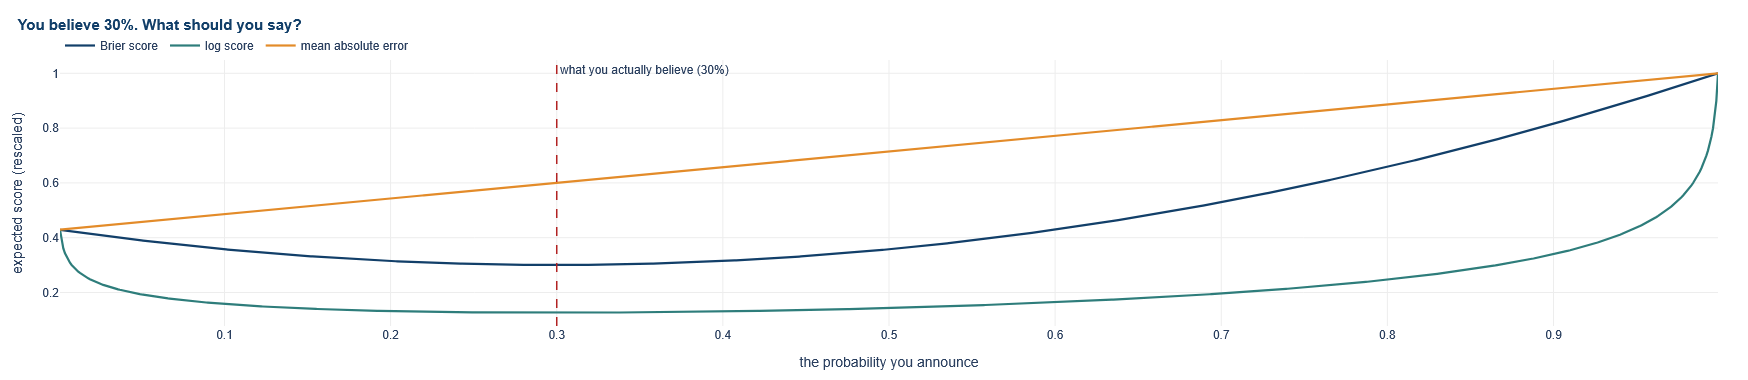

In [23]:
# Suppose you genuinely believe there is a 30% chance of rain.
# What number should you ANNOUNCE to make each score look as good as possible?
truth = 0.30
guess = np.linspace(0.001, 0.999, 999)

expected = {
    "Brier score":         truth * (guess - 1) ** 2 + (1 - truth) * guess ** 2,
    "log score":           -(truth * np.log(guess) + (1 - truth) * np.log(1 - guess)),
    "mean absolute error": truth * (1 - guess) + (1 - truth) * guess,
}
for name, curve in expected.items():
    print(f"  {name:<22} is best if you announce {guess[int(np.argmin(curve))]:.3f}")

fig = go.Figure()
for (name, curve), colour in zip(expected.items(), [NAVY, TEAL, ORANGE]):
    fig.add_trace(go.Scatter(x=guess, y=curve / curve.max(), name=name,
                             line=dict(color=colour, width=2.2)))
fig.add_vline(x=truth, line=dict(color=RED, dash="dash", width=1.5),
              annotation_text="what you actually believe (30%)")
style(fig, title="You believe 30%. What should you say?",
      xtitle="the probability you announce", ytitle="expected score (rescaled)", height=380)
fig.show()

### Proper and improper scores

**Brier and the log score are minimised at 0.30** — exactly what you believe. They are
**proper**: your best strategy is to say what you actually think. You cannot game them.

**Mean absolute error is minimised at 0.001.** It is **improper**. If you are scored on MAE,
your optimal move is to announce near-certainty in whichever direction you lean, *every
time*, no matter how unsure you are. The score pays you to hide your uncertainty. That is why
the overconfident forecaster won that column.

This is not a curiosity about weather. It generalises:

> **A quantity can only be learned, ranked or tested if a scoring function exists that is
> minimised by the truth.**

Every machine learning model you have trained was minimising a loss function. If that loss is
improper for the thing you claim to be predicting, the model will learn to be confidently
wrong — and it will look like it is winning.

Lecture 6 gives this property its name (**elicitability**) and then delivers a genuinely
awkward piece of news: the risk measure that international bank regulation now runs on has
**no scoring function of its own**. Which raises a question you are now equipped to ask —
how would anyone ever check it?

---
# Where this goes

Nothing above was about finance. All of it was about Lecture 6.

| Room | What you found | In the lecture |
| --- | --- | --- |
| 1 | your 90% was really 40% | VaR models are breached far more often than advertised |
| 2 | one measure called the dangerous game safe | VaR is not *coherent*; ES is |
| 3 | VaR certified a ruinous strategy as profitable | why Basel moved bank capital from VaR to Expected Shortfall |
| 4 | ~1,000 rolls to catch a cheat | ~10 years of data to catch a bad risk model; 250 days is the regulatory window |
| 5 | randomness is clumpier than people think | breaches cluster — the right *count* at the wrong *times* |
| 6 | the unreliable stage was not the risky one | risk contributions, and why inverse-volatility weighting is not risk parity |
| 7 | identical models made everyone worse off | procyclicality, herding, and the case against model monoculture |
| 8 | one scoring rule rewarded overconfidence | elicitability, and why Expected Shortfall cannot be backtested alone |

Two habits are worth carrying in from here.

**Ask what a number cannot see.** Every risk measure summarises a distribution into one
figure, and every summary throws something away. Room 3 is what happens when you forget what
was thrown away.

**Ask how you would know if it were wrong.** Room 4 is the answer for most risk numbers: you
probably would not, not for years. That should make you humble about the numbers you produce
and sceptical about the ones you are handed.

See you in the lecture.